We have to train a model which can predict based on adult's profile if he is getting a salary greater or lessen than 50k.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve


# Loading and inspecting

In [3]:
# in read format there are no column names getting those from kaggle site
col_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

adult_df = pd.read_csv("datasets/adult.data", names=col_names)

In [4]:
adult_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Preprocessing before splitting

### Missing values

In [6]:
adult_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

There are no null values

### Duplicated rows

In [7]:
adult_df.duplicated().sum()

np.int64(24)

Duplication can be natural so no need of removal

### Removing unnecessary columns

In [8]:
adult_df = adult_df.drop(columns=["fnlwgt"])

### Check for inconsistency in string columns

In [9]:
categorical_cols = [
    "workclass", 
    "education", 
    "marital_status", 
    "occupation", 
    "relationship", 
    "race", 
    "sex", 
    "native_country", 
    "income"
]

for col in categorical_cols:
    print(col + ":")
    print(adult_df[col].unique())

workclass:
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
education:
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
marital_status:
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation:
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']
relationship:
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']
race:
[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
sex:
[' Male' ' Female']
native_country:
[' United-States' ' Cuba' ' Jamaica' ' 

"?" detected in workclass, occupation and native country
These can be replaced with "unknown" for better clarity.
No inconsistency detected otherwise

In [10]:
replace_unknown = {" ?": "Unknown"}
unknown_cols = ["workclass", "occupation", "native_country"]
for col in unknown_cols:
    adult_df[col] = adult_df[col].replace(replace_unknown)


# Splitting

## Input and output

In [11]:
X = adult_df.drop(columns=["income"])
y = adult_df["income"]

## Train and test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Preproccessing after splitting

## Missing values

There aren't any missing values in the data

# Feature Engineering

## Encoding & scaling

### Input

In [14]:
# Three things need to be done:
# one hot encoding
# ordinal encoding + scaling
# scaling on numeric columns

ohe = OneHotEncoder(
    sparse_output=False, 
    drop="first", 
    handle_unknown="ignore"
).set_output(transform="pandas")
# Ordinal columns require scaling after they are created
scaler = StandardScaler().set_output(transform="pandas")
oe = OrdinalEncoder(
        categories=[
            [" Female", " Male"],
            [' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th', ' 11th', ' 12th', ' HS-grad', ' Some-college', ' Assoc-acdm', ' Assoc-voc',  ' Bachelors', ' Masters',  
            ' Prof-school', ' Doctorate', ]
        ]
    ).set_output(transform="pandas")
oe_pipe = Pipeline(steps=[ 
    ("ohe", oe),
    ("scaler", scaler)
])

ohe_cols = ["workclass", "marital_status", "occupation", "relationship", "race", "native_country"];
oe_cols = ["sex", "education"]
scaler_cols = ["age",  "education_num", "capital_gain", "capital_loss", "hours_per_week"]

col_transfomer = ColumnTransformer(
    transformers=[
        ("ohe", ohe, ohe_cols),
        ("oe", oe_pipe, oe_cols),
        ("scaler", scaler, scaler_cols)
    ]
).set_output(transform="pandas")

X_train = col_transfomer.fit_transform(X_train)
X_test = col_transfomer.transform(X_test)

### Output

In [15]:
oe_output = OrdinalEncoder(categories=[[' <=50K', ' >50K']])
y_train = oe_output.fit_transform(pd.DataFrame(y_train))
y_test = oe_output.transform(pd.DataFrame(y_test))

In [16]:
y_train = y_train.flatten()
y_test = y_test.flatten()

## Correlation Heatmap

In [17]:
corr_matrix = pd.concat([X_train, pd.DataFrame(y_train, columns=["income"])], axis=1).corr()
corr_matrix["income"].sort_values(ascending=False)

income                              1.000000
ohe__native_country_ Cuba           0.013788
ohe__occupation_ Farming-fishing    0.012799
ohe__native_country_ Greece         0.012776
ohe__native_country_ Italy          0.012541
                                      ...   
ohe__race_ Black                   -0.009368
ohe__workclass_Unknown             -0.011275
ohe__occupation_Unknown            -0.011351
ohe__native_country_ El-Salvador   -0.014241
ohe__occupation_ Craft-repair      -0.014335
Name: income, Length: 86, dtype: float64

<Axes: >

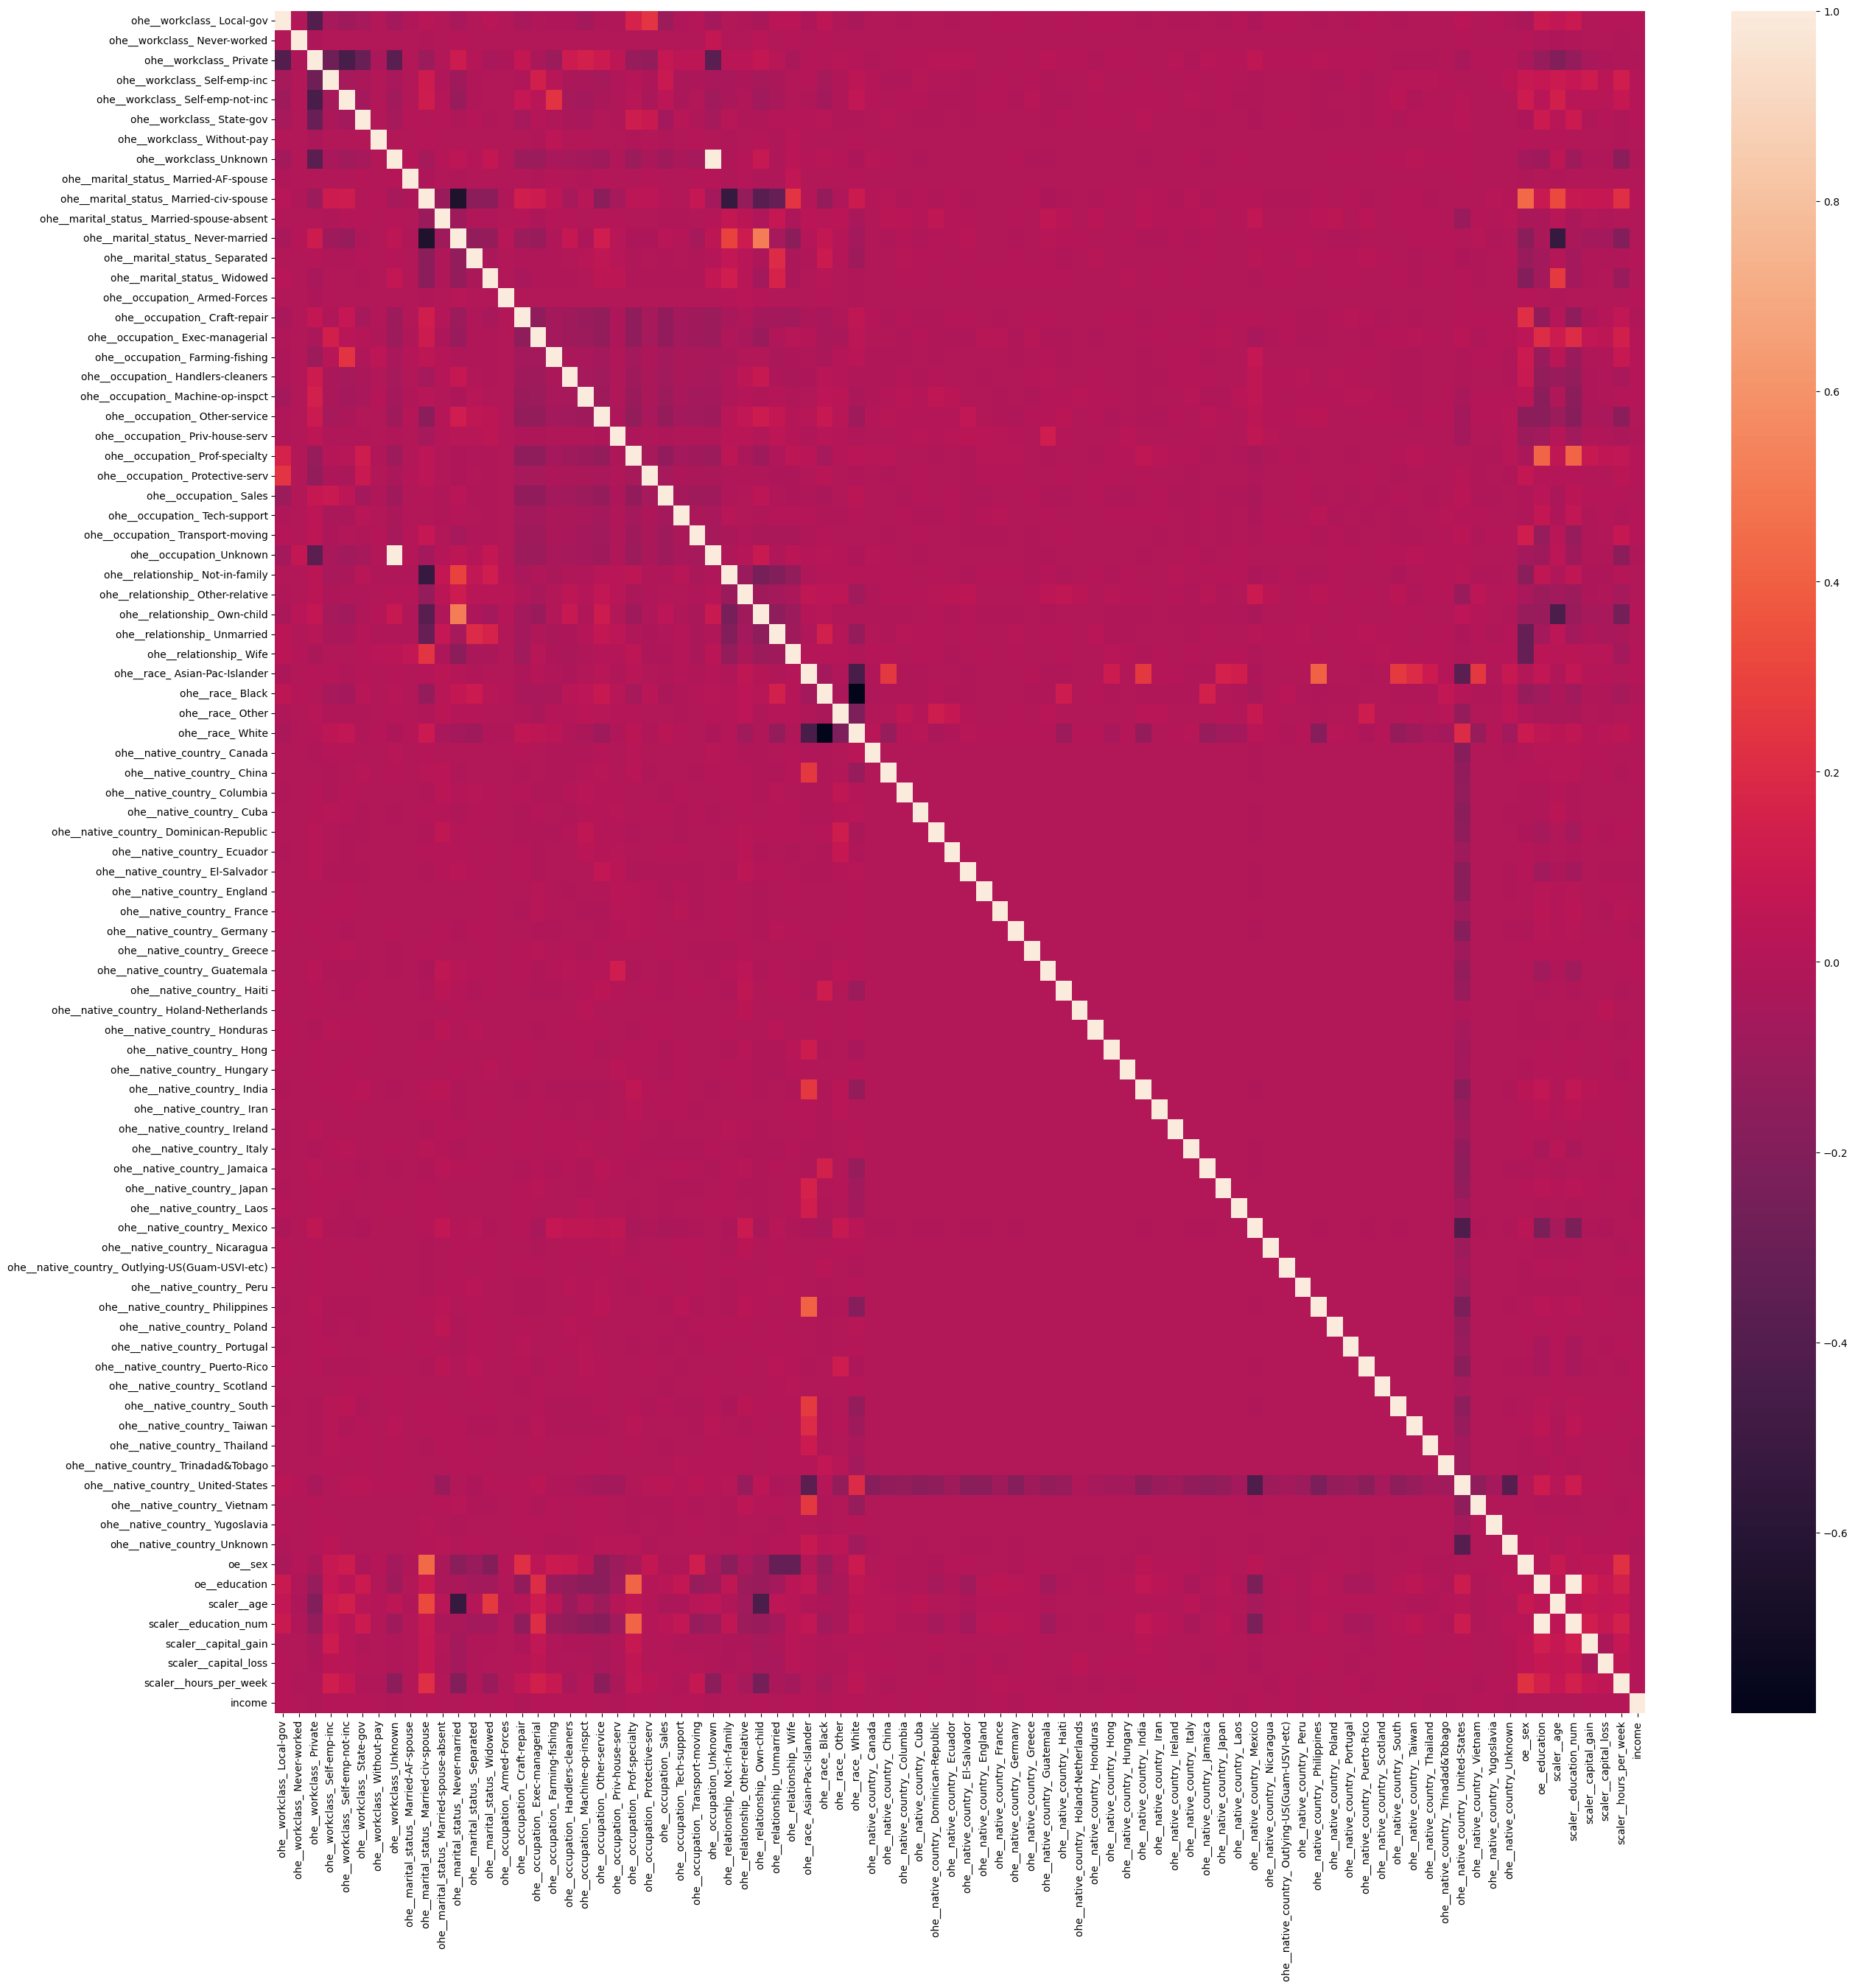

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(30, 30))
sns.heatmap(corr_matrix, ax=ax)

No strong relationship observed between any feature and income (output)

# Model training

## Naive Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## Gradient Boosting

In [20]:
gb_model = GradientBoostingClassifier()
gb_cv_model = RandomizedSearchCV(
    gb_model,
    {
        "max_depth": [1, 2, 5, 10,],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10, 50,],
    },
    cv=3,
    n_iter=15
)
gb_cv_model.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_distributions,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,n_iter,15
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## XGBoosting

In [ ]:

xgb_model = XGBClassifier()
xgb_cv_model = RandomizedSearchCV(
    xgb_model,
    {
        "max_depth": [1, 2, 5, 10,],
    },
    cv=3,
    n_iter=15,
    random_state=42
)
xgb_cv_model.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=15. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'max_depth': [1, 2, ...]}"
,n_iter,15
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Random forest

In [ ]:
rf_model = RandomForestClassifier()
rf_cv_model = RandomizedSearchCV(
    rf_model,
    {
        "max_depth": [1, 2, 5, 10,],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10, 50,],
    },
    cv=3,
    n_iter=15,
    random_state=42
)
rf_cv_model.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,n_iter,15
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Stacking

In [23]:
print(rf_cv_model.best_params_)
print(gb_cv_model.best_params_)
print(xgb_cv_model.best_params_)

{'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 10}
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}
{'max_depth': 5}


In [ ]:
sc_model = StackingClassifier(
    estimators=[
        ("gb", RandomForestClassifier(
            max_depth=10,
            min_samples_leaf=10,
            min_samples_split=2)),
        ("rf", GradientBoostingClassifier(
            max_depth=5, 
            min_samples_leaf=5,
            min_samples_split=20,
        )),
        ("xgb", XGBClassifier(
            max_depth=5
        )),
    ]
)
sc_model.fit(X_train, y_train)

,estimators,"[('gb', ...), ('rf', ...), ...]"
,final_estimator,None
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2


# Model evaluation

In [25]:
models = {
    "Naive Bayes": nb_model, 
    "GBoosting": gb_cv_model, 
    "XGBoosting": xgb_cv_model, 
    "Random forest": rf_cv_model,
    "Stacking": sc_model
}
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1:", f1_score(y_test, y_test_pred), "\n")

Naive Bayes
Accuracy: 0.4973130661753416
Precision: 0.320244880726198
Recall: 0.9656269891788669
F1: 0.4809765377298668 

GBoosting
Accuracy: 0.8777828957469676
Precision: 0.7964804896710023
Recall: 0.6626352641629535
F1: 0.7234190410006949 

XGBoosting
Accuracy: 0.8762475049900199
Precision: 0.7882441597588545
Recall: 0.6658179503500955
F1: 0.7218771566597654 

Random forest
Accuracy: 0.8565945033010901
Precision: 0.7985004686035614
Recall: 0.5423297262889879
F1: 0.6459438968915845 

Stacking
Accuracy: 0.8760939659143252
Precision: 0.7907153729071538
Recall: 0.6613621896880968
F1: 0.7202772963604853 



In [26]:
# Naive Bayes
# Accuracy: 0.4986949178565945
# Precision: 0.3207786711807025
# Recall: 0.9649904519414386
# F1: 0.4814991265682071 

# GBoosting
# Accuracy: 0.878857669276831
# Precision: 0.7989296636085627
# Recall: 0.6651814131126671
# F1: 0.7259465092045849 

# XGBoosting
# Accuracy: 0.8762475049900199
# Precision: 0.7822878228782287
# Recall: 0.6747294716740929
# F1: 0.7245386192754614 

# Random forest
# Accuracy: 0.8585905112851221
# Precision: 0.8071833648393195
# Recall: 0.5436028007638447
# F1: 0.6496766831494865 

# Stacking
# ...
# Precision: 0.7905405405405406
# Recall: 0.6702737110120942
# F1: 0.7254564243885635 
